In [1]:
%matplotlib inline
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l

In [2]:
#@save
d2l.DATA_HUB['banana-detection'] = (
    d2l.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

In [3]:
#@save
def read_data_bananas(is_train=True):
    """读取香蕉检测数据集中的图像和标签"""
    data_dir = d2l.download_extract('banana-detection')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
#     这一行构造标签文件的路径：
# os.path.join(...)：跨平台拼路径（Windows/Linux 都适用）。
# 中间那段：
# 若 is_train=True → 'bananas_train'
# 否则 → 'bananas_val'
# 最后拼上 'label.csv'
# 所以：
# 训练集标签：<data_dir>/bananas_train/label.csv
# 验证集标签：<data_dir>/bananas_val/label.csv
    
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
#     把 img_name 这一列设置成 DataFrame 的索引（index）。
# 这样之后遍历时可以直接得到：
# img_name（索引）
# target（这一行其余列组成的 Series）
    
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        # 这里的target包含（类别，左上角x，左上角y，右下角x，右下角y），
        # 其中所有图像都具有相同的香蕉类（索引为0）
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

In [4]:
#@save
class BananasDataset(torch.utils.data.Dataset):
    """一个用于加载香蕉检测数据集的自定义数据集"""
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
#         调用你前面写的 read_data_bananas(is_train)：
# 返回 features：一个 list，里面每个元素是一张图片张量，形状通常 (C,H,W)，dtype 一般是 uint8。
# 返回 labels：一个 tensor，形状通常 (N, 1, 5)（每张图 1 个真实框），内容 [class, x1, y1, x2, y2]（坐标通常已归一化）。
        
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

In [7]:
#@save
def load_data_bananas(batch_size):
    """加载香蕉检测数据集"""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    BananasDataset(is_train=True)
# 创建一个训练集 Dataset 对象。
# 其内部会调用 read_data_bananas(True)：
# 读 bananas_train/images/ 下的图片
# 读 bananas_train/label.csv 下的标签
# 并打印类似：
# read XXX training examples
# (2) torch.utils.data.DataLoader(...)
# 用 DataLoader 包装 Dataset，DataLoader 负责：
# 按 batch 取数据
# 打乱顺序（如果 shuffle=True）
# 自动堆叠成 batch 张量（默认 collate）
# （可选）多进程并行加载（这里没指定 num_workers，默认 0）
# (3) batch_size
# 你传入的 batch_size 决定每次 for X, y in train_iter: 里 X/y 的 batch 维度大小。
# (4) shuffle=True
# 训练集一般要打乱，避免模型每个 epoch 都按固定顺序看到数据，提升训练稳定性和泛化。
# 验证集通常不需要打乱。
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

In [8]:
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
# 调用你之前写的 load_data_bananas，返回：
# train_iter：训练 DataLoader
# _：验证 DataLoader（用 _ 表示“我不关心这个返回值”）
batch = next(iter(train_iter))
# iter(train_iter)：把 DataLoader 变成一个迭代器。
# next(...)：取迭代器的第一个元素，也就是第一个 batch。
# batch 是一个二元组：
# batch[0]：图片 batch
# batch[1]：标签 batch
batch[0].shape, batch[1].shape

read 1000 training examples
read 1000 training examples
read 100 validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

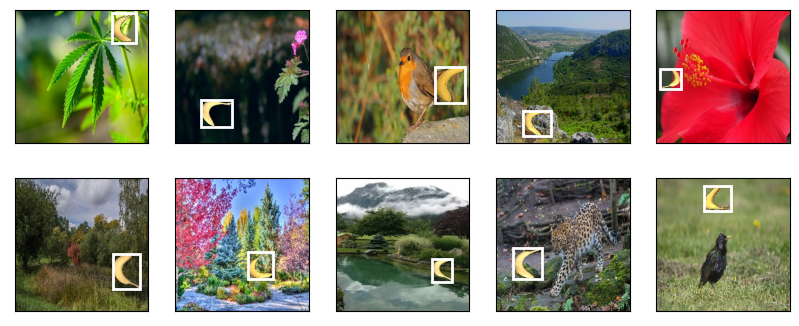

In [9]:
imgs = (batch[0][0:10].permute(0, 2, 3, 1)) / 255
axes = d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][0:10]):
    d2l.show_bboxes(ax, [label[0][1:5] * edge_size], colors=['w'])